# SPHERE IFS Extraction

In this tutorial, we will extract SPHERE IFS observations
at multiple wavelength. A lot of the parameters are the same
as in the [SPHERE extraction tutorial](../sphere-extraction/),
but here we iterate over multiple wavelengths.

In [1]:
from astropy.io import fits

import amical

## SPHERE IFS Data

In [2]:
file_ifs = "../NRM_DATA/example_sphere_ifs.fits"

hdul = fits.open(file_ifs)
hdul.info()
hdul.close()

Filename: ../NRM_DATA/example_sphere_ifs.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCIDATA       1 PrimaryHDU    1156   (291, 291, 3, 39)   float32   


As we can see above, the IFS observation is a cube of 3 integrations with 291x291 pixels and there are 39 wavelengths.

## AMICAL parameters

Since the extraction below is done in a loop, we will first set the cleaning and extraction parameters.

In [3]:
# Set your own cleaning paramters (appropriate for SPHERE)
clean_param = {"isz": 149, "r1": 70, "dr": 2, "apod": True, "window": 65, "f_kernel": 3}

In [4]:
# Set the AMICAL parameters
params_ami = {
    "peakmethod": "fft",
    "bs_multi_tri": False,
    "maskname": "g7",
    "fw_splodge": 0.7,
    "filtname": "YJ",  # Use the appropriate filter (only YJ and YH implemented)
}

We also need to specify the list of spectral channels (wavelengths) that we want to extract.
Here we use only three to keep things short, but we could also specify all wavelengths with
`np.arange(39)`.

AMICAL can then fetch the wavelength values based on the list of indices.

In [5]:
list_index_ifu = [0, 10, 20]

wave = amical.get_infos_obs.get_ifu_table(
    list_index_ifu, filtname=params_ami["filtname"]
)
print(f"Wavelengths used: {wave} µm")

Wavelengths used: [0.9575572 1.05019   1.1540903] µm


## Data processing

Now that we have everything set-up, we can iterate over the wavelength indices
to clean the data and extract the observables.

If we had a reference star observation, we could also run `amical.calibrate` for
each wavelength individually.

In [6]:
l_cal = []
for i_wl in list_index_ifu:
    # Step 1: clean the data (only one wave at a time: i_wl index)
    cube_clean = amical.select_clean_data(file_ifs, i_wl=i_wl, **clean_param)

    # Step 2: extract data (i_wl must be specified to use the good bandwidth and
    # central wavelength (automatical in AMICAL).
    bs_ifs = amical.extract_bs(
        cube_clean,
        file_ifs,
        i_wl=i_wl,
        display=i_wl == list_index_ifu[0],
        **params_ami,
    )

    # We convert the raw variable into appropriate format for visualisation
    cal = amical.oifits.wrap_raw(bs_ifs)

    # We save all wavelength into the same list
    l_cal.append(cal)

Output()

Output()

Output()

Finally, we can then take a look at the multi-wavelength observables.


 -- SHOW -- Inputs are classes from amical.calibrate:
-> (Check true_flag_v2, true_flag_t3 and snr parameters)



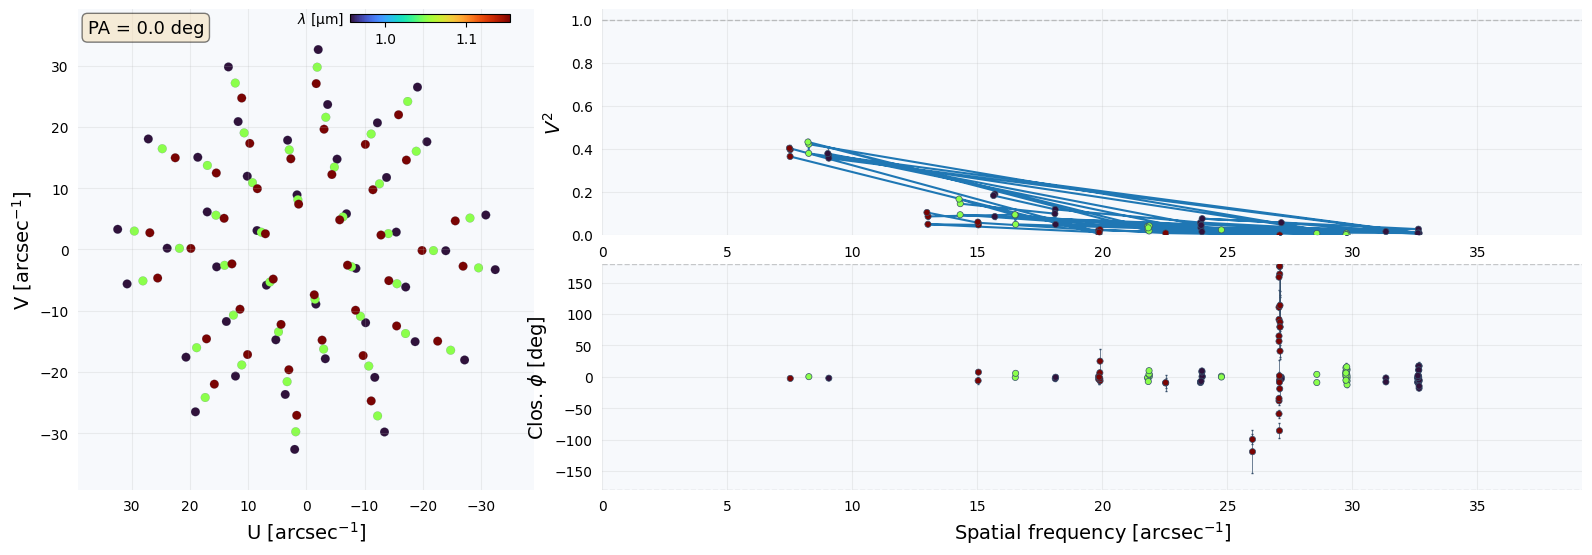

In [7]:
_ = amical.show(l_cal)